<a href="https://colab.research.google.com/github/ujjwaltiwari1204-glitch/smart-grid-fault-detection/blob/main/fault_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving detect_dataset.csv to detect_dataset.csv


In [1]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
df = pd.read_csv('detect_dataset.csv')
df = df.drop(columns=['Unnamed: 7', 'Unnamed: 8'])
print("Ready! Shape:", df.shape)

Saving detect_dataset.csv to detect_dataset.csv
Ready! Shape: (12001, 7)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('detect_dataset.csv')

print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (12001, 9)

Column names: ['Output (S)', 'Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc', 'Unnamed: 7', 'Unnamed: 8']

First 5 rows:


,Output (S),Ia,Ib,Ic,Va,Vb,Vc,Unnamed: 7,Unnamed: 8
0,0,-170.472196,9.219613,161.252583,0.054490,-0.659921,0.605431,NaN,NaN
1,0,-122.235754,6.168667,116.067087,0.102000,-0.628612,0.526202,NaN,NaN
2,0,-90.161474,3.813632,86.347841,0.141026,-0.605277,0.464251,NaN,NaN
3,0,-79.904916,2.398803,77.506112,0.156272,-0.602235,0.445963,NaN,NaN
4,0,-63.885255,0.590667,63.294587,0.180451,-0.591501,0.411050,NaN,NaN


Missing values:
 Output (S)    0
Ia            0
Ib            0
Ic            0
Va            0
Vb            0
Vc            0
dtype: int64

Fault distribution:
Output (S)
0    6505
1    5496
Name: count, dtype: int64


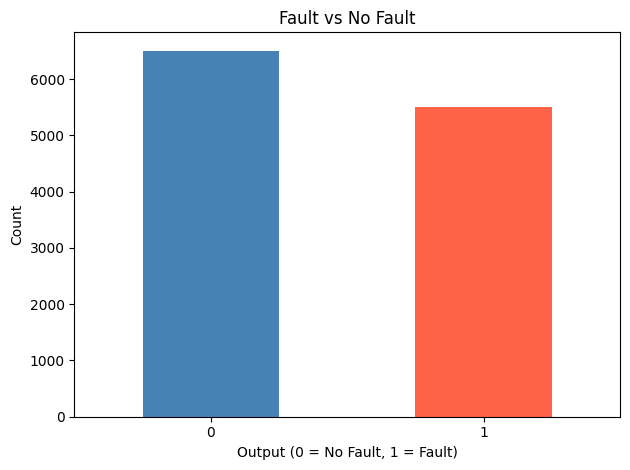

In [ ]:
# Drop garbage columns
df = df.drop(columns=['Unnamed: 7', 'Unnamed: 8'])

# Check for missing values
print("Missing values:\n", df.isnull().sum())

# Check fault distribution
print("\nFault distribution:")
print(df['Output (S)'].value_counts())

# Plot fault distribution
df['Output (S)'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Fault vs No Fault')
plt.xlabel('Output (0 = No Fault, 1 = Fault)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

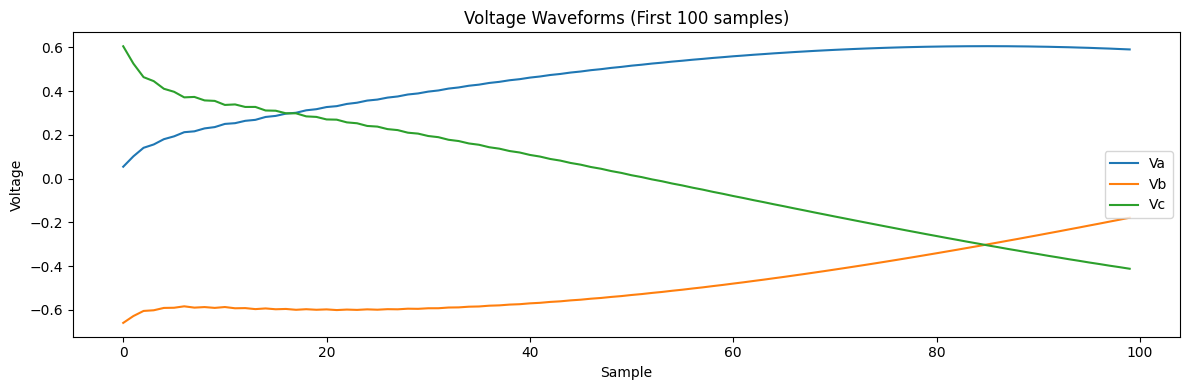

In [ ]:
# Plot voltage waveforms for first 100 rows
plt.figure(figsize=(12, 4))
plt.plot(df['Va'][:100], label='Va')
plt.plot(df['Vb'][:100], label='Vb')
plt.plot(df['Vc'][:100], label='Vc')
plt.title('Voltage Waveforms (First 100 samples)')
plt.xlabel('Sample')
plt.ylabel('Voltage')
plt.legend()
plt.tight_layout()
plt.show()

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Step 1 - Separate features and label
X = df.drop(columns=['Output (S)'])  # input columns (Ia, Ib, Ic, Va, Vb, Vc)
y = df['Output (S)']                 # output column (0 or 1)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nSample of y (labels):", y.value_counts().to_dict())

X shape: (12001, 6)
y shape: (12001,)

Sample of y (labels): {0: 6505, 1: 5496}


In [3]:
# Step 2 - Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 9600
Testing samples: 2401


In [4]:
# Step 3 - Train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [5]:
# Step 4 - Test the model
y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

print("\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names=['No Fault', 'Fault']))

Accuracy: 99.79%

Detailed Report:
              precision    recall  f1-score   support

    No Fault       1.00      1.00      1.00      1306
       Fault       1.00      1.00      1.00      1095

    accuracy                           1.00      2401
   macro avg       1.00      1.00      1.00      2401
weighted avg       1.00      1.00      1.00      2401



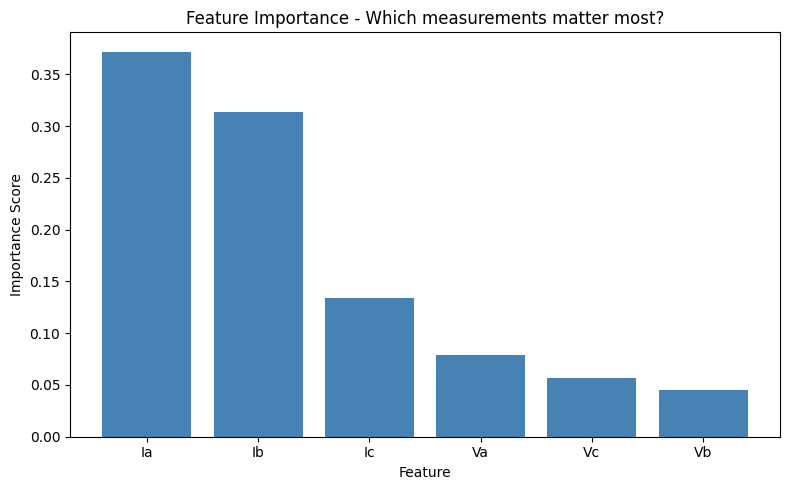


Feature importance ranking:
Ia: 0.3720
Ib: 0.3134
Ic: 0.1338
Va: 0.0785
Vc: 0.0568
Vb: 0.0454


In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances
features = X.columns
importances = rf_model.feature_importances_

# Sort by importance
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(8, 5))
plt.bar(range(len(features)), importances[indices], color='steelblue')
plt.xticks(range(len(features)), [features[i] for i in indices])
plt.title('Feature Importance - Which measurements matter most?')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

# Print values too
print("\nFeature importance ranking:")
for i in indices:
    print(f"{features[i]}: {importances[i]:.4f}")

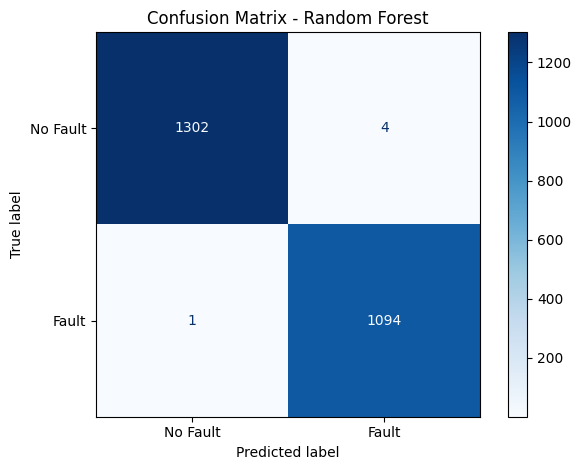


Confusion Matrix values:
True No Fault (correct): 1302
False Fault (wrong alarm): 4
Missed Fault (dangerous!): 1
True Fault (correct): 1094


In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Fault', 'Fault'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.show()

print("\nConfusion Matrix values:")
print(f"True No Fault (correct): {cm[0][0]}")
print(f"False Fault (wrong alarm): {cm[0][1]}")
print(f"Missed Fault (dangerous!): {cm[1][0]}")
print(f"True Fault (correct): {cm[1][1]}")

In [8]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf_model, X, y, cv=5)

print("Cross Validation scores for each fold:")
for i, score in enumerate(cv_scores):
    print(f"Fold {i+1}: {score*100:.2f}%")

print(f"\nAverage CV Accuracy: {cv_scores.mean()*100:.2f}%")
print(f"Standard Deviation: {cv_scores.std()*100:.2f}%")

Cross Validation scores for each fold:
Fold 1: 94.09%
Fold 2: 99.17%
Fold 3: 82.83%
Fold 4: 98.50%
Fold 5: 100.00%

Average CV Accuracy: 94.92%
Standard Deviation: 6.38%


In [9]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# SVM needs scaled data unlike Random Forest
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)

svm_pred = svm_model.predict(X_test_scaled)
svm_accuracy = accuracy_score(y_test, svm_pred)
print(f"SVM Accuracy: {svm_accuracy*100:.2f}%")
print(f"Random Forest Accuracy: 99.79%")
print(f"\nWinner: {'Random Forest' if 99.79 > svm_accuracy*100 else 'SVM'}")

SVM Accuracy: 98.38%
Random Forest Accuracy: 99.79%

Winner: Random Forest
